### (0) Import libraries

Enter particle (proton, alpha, carbon):  alpha
Enter initial KE (MeV):  400
Enter step size dx (cm, e.g., 0.01):  0.01
Enter material density rho (g/cm^3):  1.04
Enter material Z/A (e.g., 0.55 for skeletal muscle):  0.55
Enter mean excitation energy I (MeV, e.g., 75.3e-6):  75.3e-6
Enter zoom length for Bragg peak (cm, e.g., 2.0):  2.0


Range in material = 7.559999999999883 cm


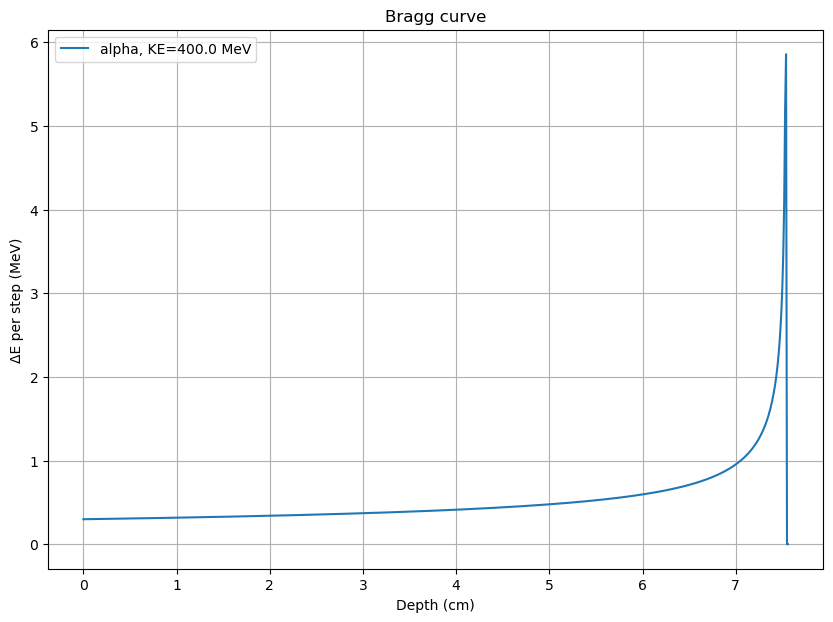

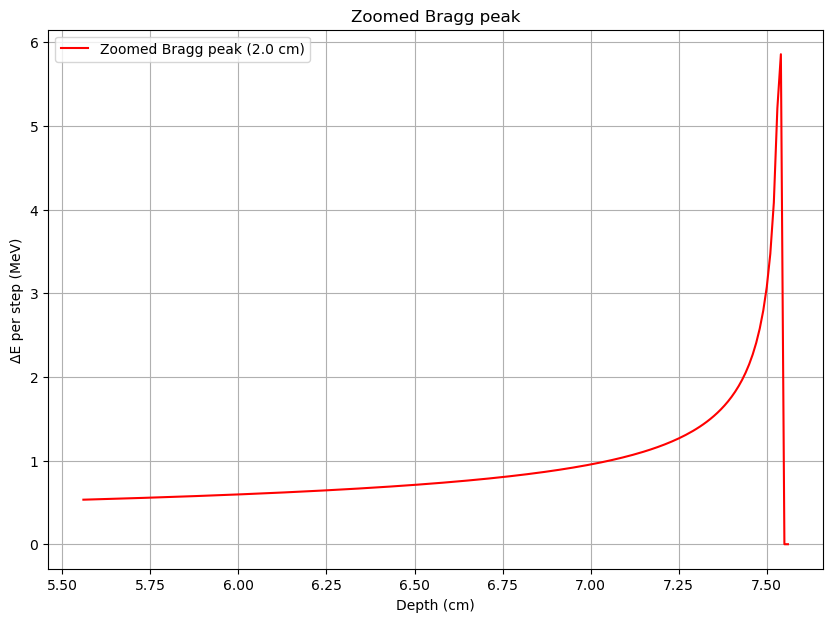

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# example given: skeletal muscle (from NIST)
def compute_bragg_curve(
    particle="proton",
    E0=120.0, # MeV
    dx=0.01, # cm
    rho=1.04,# g/cm^3
    ZoverA=0.55,
    I=75.3e-6, # MeV
    zoomin=1.5 # cm for zoomed peak
):

    # (1) particle choice
    particle = particle.lower()
    if particle == "proton":
        z = 1
        mc2 = 938.272
    elif particle == "alpha":
        z = 2
        mc2 = 3727.379
    elif particle == "carbon":
        z = 6
        mc2 = 11177.93
    else:
        raise ValueError("Unknown particle")
    
    # (2) constants and additional parameters
    mec2 = 0.511
    K = 0.307

    depths = [0.0]
    KEs = [E0]
    deltaEs = []
    linSPs = []

    E = E0
    x = 0.0
    max_steps = int(1e6)

    # (3) Calculate stopping power and energy loss
    for i in range(max_steps):
        gamma = 1 + E / mc2 # lorentz factor
        betasq = 1 - 1 / gamma**2
        betasq = np.clip(betasq, 1e-12, 1-1e-12)
        firstTerm = K * ZoverA * (z**2 / betasq)
        logTerm = np.log((2 * mec2 * betasq) / (I * (1 - betasq)))
        massSP = firstTerm * (logTerm - betasq) # mass stopping power
        linSP = massSP * rho # linear stopping power
        dE = linSP * dx
        if dE > E:
            dE = E
            E = 0
        else:
            E -= dE
        x += dx
        depths.append(x)
        KEs.append(E)
        deltaEs.append(dE)
        linSPs.append(linSP)

        if E <= 0:
            depths.append(x + dx)
            KEs.append(0.0) # to see the Bragg peak
            deltaEs.append(0.0) # "
            linSPs.append(linSP)
            break

    depths = np.array(depths)
    deltaEs_full = np.array(deltaEs + [0.0]) # padding

    # (5) Results
    # CSDA Range
    print("Range in material =",depths[-1], "cm")
    
    # Full Bragg plot
    plt.figure(figsize=(10,7))
    plt.plot(depths, deltaEs_full, label=f"{particle}, KE={E0} MeV")
    plt.xlabel("Depth (cm)")
    plt.ylabel("ΔE per step (MeV)")
    plt.title("Bragg curve")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Zoomed on the Bragg peak
    zoom_start = depths[-1] - zoomin
    zoom_mask = depths >= zoom_start
    plt.figure(figsize=(10,7))
    plt.plot(depths[zoom_mask], deltaEs_full[zoom_mask], color="red",
             label=f"Zoomed Bragg peak ({zoomin} cm)")
    plt.xlabel("Depth (cm)")
    plt.ylabel("ΔE per step (MeV)")
    plt.title("Zoomed Bragg peak")
    plt.grid(True)
    plt.legend()
    plt.show()
    return depths, deltaEs_full


# (6) GUI
particle = input("Enter particle (proton, alpha, carbon): ").strip().lower()
E0 = float(input("Enter initial KE (MeV): "))
dx = float(input("Enter step size dx (cm, e.g., 0.01): "))
rho = float(input("Enter material density rho (g/cm^3): "))
ZoverA = float(input("Enter material Z/A (e.g., 0.55 for skeletal muscle): "))
I = float(input("Enter mean excitation energy I (MeV, e.g., 75.3e-6): "))
zoomin = float(input("Enter zoom length for Bragg peak (cm, e.g., 2.0): "))

depths, deltaEs = compute_bragg_curve(
    particle=particle,
    E0=E0,
    dx=dx,
    rho=rho,
    ZoverA=ZoverA,
    I=I,
    zoomin=zoomin
)